In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data():
    global df
    df=pd.read_csv("Data/IPL.csv",low_memory=False)
load_data()

def inspect_data():
    print(df.shape)
    print(df.columns)
    print(df.head(5))
    print(df.info())
    print(df.isnull().sum().sort_values(ascending=False))

def clean_data():
    df['city'] = df['city'].fillna('Unknown')
    df['player_of_match'] = df['player_of_match'].fillna('None')
    df['match_won_by'] = df['match_won_by'].fillna('No Result')
    df['win_outcome'] = df['win_outcome'].fillna('No Result')
    df.drop_duplicates(inplace=True)
clean_data()

def team_wins():
    match_level=df[['match_id','match_won_by']].drop_duplicates()
    team_wins = match_level['match_won_by'].value_counts()
    print(team_wins.head(20))

def team_analysis():
    global win_percent
    match_level = df[['match_id','match_won_by']].drop_duplicates()
    team_wins = match_level['match_won_by'].value_counts()
    total_matches = match_level['match_id'].nunique()
    win_percent = (team_wins / total_matches) * 100
    print("Team Win Percentage:\n")
    print(win_percent.sort_values(ascending=False))

def team_analysis_visualization():
    x=win_percent.head(20)
    plt.bar(x.index,x.values)
    plt.title("Top Teams by Win %")
    plt.xlabel("Teams")
    plt.ylabel("Win Percentage")
    plt.xticks(rotation=90)
    plt.show()

def toss_analysis():
    global toss_impact
    match_level = df[['match_id','toss_winner','match_won_by']].drop_duplicates()
    match_level['toss_match_same'] = (match_level['toss_winner'] == match_level['match_won_by'])
    toss_impact = match_level['toss_match_same'].mean() * 100
    print("Toss Winning Team also Wins Match:", round(toss_impact, 2), "%")

def toss_analysis_visualization():
    match_level = df[['match_id','toss_winner','match_won_by']].drop_duplicates()
    match_level['toss_match_same'] = (match_level['toss_winner'] == match_level['match_won_by'])
    values = [match_level['toss_match_same'].sum(),len(match_level) - match_level['toss_match_same'].sum()]
    labels = ['Won Match', 'Lost Match']
    plt.pie(values, labels=labels, autopct='%1.1f%%')
    plt.title("Toss Impact on Match Result")
    plt.show()

def batter_analysis():
    top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)
    print("Top Batters:\n")
    print(top_batters)

def batter_analysis_visualization():
    top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)
    x=top_batters
    plt.bar(x.index, x.values)
    plt.title("Top 10 Batters")
    plt.xlabel("Batters")
    plt.ylabel("Runs")
    plt.xticks(rotation=90)
    plt.show()

def bowlers_analysis():
    top_bowlers = df.groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False).head(10)
    print("\nTop Bowlers:\n")
    print(top_bowlers)

def bowlers_analysis_visualization():
    top_bowlers = df.groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False).head(10)
    x=top_bowlers
    plt.bar(x.index, x.values)
    plt.title("Top 10 Bowlers")
    plt.xlabel("Bowlers")
    plt.ylabel("Wickets")
    plt.xticks(rotation=90)
    plt.show()

def mvp_analysis():
    global top_mvp
    match_level = df[['match_id','player_of_match']].drop_duplicates()
    top_mvp = match_level['player_of_match'].value_counts().head(10)
    print("\nTop Player of Match:\n")
    print(top_mvp)
    
def mvp_analysis_visualization():
    x=top_mvp
    plt.bar(x.index, x.values)
    plt.title("Top 10 MVP")
    plt.xlabel("Player")
    plt.ylabel("Matches")
    plt.xticks(rotation=90)
    plt.show()

def head_to_head(team1, team2):
    match_level = df[['match_id', 'batting_team', 'bowling_team', 'match_won_by']].drop_duplicates()
    data = match_level[((match_level['batting_team'] == team1) | (match_level['bowling_team'] == team1)) &((match_level['batting_team'] == team2) | (match_level['bowling_team'] == team2))]
    team1_wins = data[data['match_won_by'] == team1].shape[0]
    team2_wins = data[data['match_won_by'] == team2].shape[0]
    print(f"\n{team1} vs {team2}")
    print(f"{team1} Wins: {team1_wins}")
    print(f"{team2} Wins: {team2_wins}")

In [10]:
def team_menu():
    while True:
        print("\n--- TEAM ANALYSIS ---")
        print("1. Overall Team Performance")
        print("2. Head to Head Comparison")
        print("3. Visualization")
        print("4. Back")
        choice = input("Enter choice: ")
        if choice == '1':
            team_analysis()
        elif choice == '2':
            team1 = input("Enter Team 1: ")
            team2 = input("Enter Team 2: ")
            head_to_head(team1, team2)
        elif choice == '3':
            team_analysis_visualization()
        elif choice == '4':
            break
        else:
            print("Invalid choice")

def toss_menu():
    while True:
        print("\n--- TOSS ANALYSIS ---")
        print("1. Text Analysis")
        print("2. Visualization")
        print("3. Back")
        choice = input("Enter choice: ")
        if choice == '1':
            toss_analysis()
        elif choice == '2':
            toss_analysis_visualization()
        elif choice == '3':
            break
        else:
            print("Invalid choice")

def batter_menu():
    while True:
        print("\n--- BATTER ANALYSIS ---")
        print("1. Text Analysis")
        print("2. Visualization")
        print("3. Back")
        choice = input("Enter choice: ")
        if choice == '1':
            batter_analysis()
        elif choice == '2':
            batter_analysis_visualization()
        elif choice == '3':
            break
        else:
            print("Invalid choice")

def bowler_menu():
    while True:
        print("\n--- BOWLER ANALYSIS ---")
        print("1. Text Analysis")
        print("2. Visualization")
        print("3. Back")
        choice = input("Enter choice: ")
        if choice == '1':
            bowlers_analysis()
        elif choice == '2':
            bowlers_analysis_visualization()
        elif choice == '3':
            break
        else:
            print("Invalid choice")

def mvp_menu():
    while True:
        print("\n--- MVP ANALYSIS ---")
        print("1. Text Analysis")
        print("2. Visualization")
        print("3. Back")
        choice = input("Enter choice: ")
        if choice == '1':
            mvp_analysis()
        elif choice == '2':
            mvp_analysis_visualization()
        elif choice == '3':
            break
        else:
            print("Invalid choice")

def h2h_menu():
    team1 = input("Enter Team 1: ")
    team2 = input("Enter Team 2: ")
    head_to_head(team1, team2)

def insights():
    print("\n===== KEY INSIGHTS =====\n")
    print("1. Dominant Team:", win_percent.idxmax())
    print("2. Most MVP:", top_mvp.index[0])
    print("3. Toss Impact:", round(toss_impact, 2), "%")
    print("4. Insight: IPL shows team dominance over individual randomness.")
    print("5. Insight: Toss has moderate influence, not decisive always.")


========== IPL ANALYSIS MENU ==========
1. Team Analysis
2. Toss Analysis
3. Batter Analysis
4. Bowler Analysis
5. MVP Analysis
6. Insights
7. Exit


Enter your choice:  5



--- MVP ANALYSIS ---
1. Text Analysis
2. Visualization
3. Back


Enter choice:  1



Top Player of Match:

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
MS Dhoni          18
DA Warner         18
SP Narine         17
AD Russell        16
RA Jadeja         16
SR Watson         16
Name: count, dtype: int64

--- MVP ANALYSIS ---
1. Text Analysis
2. Visualization
3. Back


Enter choice:  2


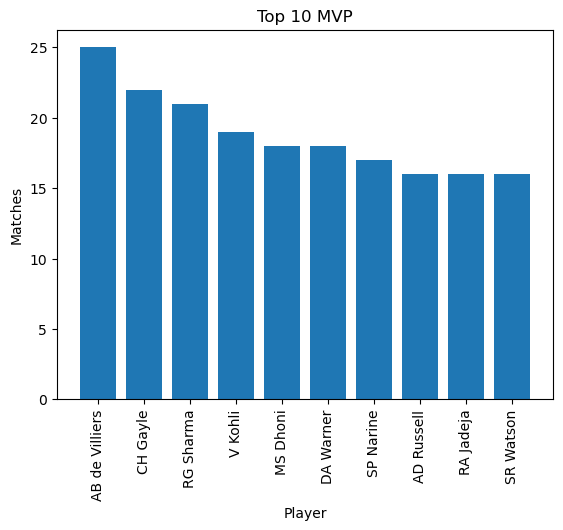


--- MVP ANALYSIS ---
1. Text Analysis
2. Visualization
3. Back


Enter choice:  3



========== IPL ANALYSIS MENU ==========
1. Team Analysis
2. Toss Analysis
3. Batter Analysis
4. Bowler Analysis
5. MVP Analysis
6. Insights
7. Exit


Enter your choice:  6



===== KEY INSIGHTS =====

1. Dominant Team: Mumbai Indians
2. Most MVP: AB de Villiers
3. Toss Impact: 50.8 %
4. Insight: IPL shows team dominance over individual randomness.
5. Insight: Toss has moderate influence, not decisive always.

========== IPL ANALYSIS MENU ==========
1. Team Analysis
2. Toss Analysis
3. Batter Analysis
4. Bowler Analysis
5. MVP Analysis
6. Insights
7. Exit


Enter your choice:  7


Exiting...


In [16]:
def menu():
    while True:
        print("\n========== IPL ANALYSIS MENU ==========")
        print("1. Team Analysis")
        print("2. Toss Analysis")
        print("3. Batter Analysis")
        print("4. Bowler Analysis")
        print("5. MVP Analysis")
        print("6. Insights")
        print("7. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            team_menu()
        elif choice == '2':
            toss_menu()
        elif choice == '3':
            batter_menu()
        elif choice == '4':
            bowler_menu()
        elif choice == '5':
            mvp_menu()
        elif choice == '6':
            insights() 
        elif choice == '7':
            print("Exiting...")
            break
        else:
            print("Invalid choice")
menu()